# Part VII — Calculus: The Mathematics of Change

**Chapters 201–240**

---

## What This Part Covers

Every neural network you train, every optimization algorithm you run, every physical simulation you build relies on calculus. Not as a formality — as the actual computational engine.

This Part builds calculus from the programmer's perspective: numerical, visual, and applied. You will implement derivatives, gradients, integrals, and differential equation solvers from scratch. By the end, backpropagation will be obvious, not mysterious.

**Chapter map:**

| Range | Topic Cluster |
|-------|---------------|
| 201–204 | Motivation, limits, the concept of change |
| 205–208 | Derivatives: tangent lines → automatic differentiation |
| 209–214 | Gradients, partial derivatives, optimization landscapes |
| 215–216 | Chain rule and backpropagation |
| 217–220 | Second derivatives, curvature, Taylor series |
| 221–224 | Integration: area, numerical methods, Monte Carlo |
| 225–227 | Differential equations and gradient-based learning |
| 228–230 | Projects: gradient descent, linear regression, logistic regression |
| 231–240 | Advanced experiments |

---

## The Mental Shift

Parts I–VI dealt largely with **static objects**: numbers, functions evaluated at a point, vectors, matrices, transformations. The question was always *what is this thing?*

Calculus asks a different question: **how does this thing change?**

This shift is enormous. Once you can describe change mathematically, you can:
- Find the minimum of a loss function (training a model)
- Propagate error signals backward through a network (backpropagation)
- Describe how a population or epidemic evolves over time
- Integrate probability distributions to compute expected values

The key objects are:

- **Derivative**: the instantaneous rate of change of a function
- **Gradient**: the multidimensional generalization of the derivative
- **Integral**: accumulation of change over an interval
- **Differential equation**: a function defined by its own rate of change

---

## Prerequisites from Prior Parts

- **Functions** (Part III, ch051–090): You must be comfortable with f(x) notation, composition, and function families. Derivatives act on functions.
- **Vectors and dot products** (Part V, ch121–150): Gradients are vectors. Gradient descent moves in vector space.
- **Matrix multiplication** (Part VI, ch151–165): The Jacobian and backpropagation are matrix operations.
- **Linear transformations** (Part VI, ch164–168): Understanding how matrices transform space clarifies why the chain rule looks the way it does.

---

## Motivating Problem: Train a Neural Network Layer

You cannot yet solve the following. You will be able to by ch227.

The problem: given a dataset of inputs and targets, adjust the weights of a single linear layer to minimize prediction error — using only the gradient of the loss with respect to every weight.

Run the cell below. It will fail to converge because the gradient update is missing. Your job in this Part is to understand every line of what's missing and why.

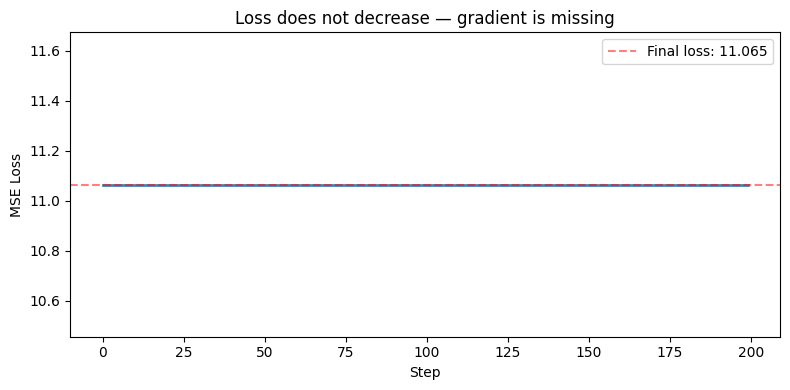

True weights: [3.0, -2.0], bias: 1.0
Learned weights: [0. 0.], bias: 0.0000

The model did not learn. It needs gradients. That is what this Part teaches.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Dataset: y = 3x1 + -2x2 + 1 + noise
N = 100
X = np.random.randn(N, 2)
y_true = X @ np.array([3.0, -2.0]) + 1.0 + 0.3 * np.random.randn(N)

# Model: linear layer — y_hat = X @ w + b
w = np.zeros(2)
b = 0.0
lr = 0.01
losses = []

for step in range(200):
    y_hat = X @ w + b
    residuals = y_hat - y_true
    loss = np.mean(residuals ** 2)  # MSE
    losses.append(loss)

    # ??? — gradient of loss w.r.t. w and b goes here
    # You do not yet know how to compute this.
    # After Part VII, you will derive it from first principles.
    grad_w = np.zeros(2)   # placeholder — wrong
    grad_b = 0.0           # placeholder — wrong

    w -= lr * grad_w
    b -= lr * grad_b

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses, color='steelblue', linewidth=2)
ax.set_xlabel('Step')
ax.set_ylabel('MSE Loss')
ax.set_title('Loss does not decrease — gradient is missing')
ax.axhline(y=losses[-1], color='red', linestyle='--', alpha=0.5, label=f'Final loss: {losses[-1]:.3f}')
ax.legend()
plt.tight_layout()
plt.show()

print(f'True weights: [3.0, -2.0], bias: 1.0')
print(f'Learned weights: {w}, bias: {b:.4f}')
print('\nThe model did not learn. It needs gradients. That is what this Part teaches.')

---

## What Connects to What

```
Limits (ch203–204)
       ↓
Derivatives (ch205–207) ──→ Automatic Differentiation (ch208)
       ↓                              ↓
Gradients (ch209–211)         Chain Rule (ch215)
       ↓                              ↓
Gradient Descent (ch212–214)  Backpropagation (ch216)
       ↓                              ↓
Second Derivatives / Curvature (ch217–218)
       ↓
Taylor Series (ch219–220)
       ↓
Integration (ch221–224) ──→ Monte Carlo (ch224)
       ↓
Differential Equations (ch225–226)
       ↓
Gradient-Based Learning (ch227)
       ↓
Projects (ch228–230): Visualizer, Linear Regression, Logistic Regression
```

---

## A Note on Rigor

Classical calculus courses spend weeks on epsilon-delta proofs of limits. We will not. Not because rigor is unimportant — but because the programmer's path to calculus runs through numerical computation, not formal analysis.

You will compute derivatives numerically before you use closed-form rules. You will approximate integrals before you apply the fundamental theorem. This order is deliberate: seeing *why* the formulas work is more valuable than memorizing them.

When you reach the projects, you will have both the intuition and the tools to implement gradient descent from scratch, with no libraries.